# Clouds Everywhere — Demo
Check satellite image availability over any AOI by cloud-cover threshold.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from clouds_everywhere.aoi import to_bbox
from clouds_everywhere.search import search_images
from clouds_everywhere.coverage import check_coverage
from clouds_everywhere.viz import plot_coverage_heatmap
import pandas as pd

print('Library loaded.')

Library loaded.


## 1. AOI input variants

`to_bbox()` accepts four different formats and always returns a WGS84
`[minX, minY, maxX, maxY]` bbox, reprojecting automatically when needed.

In [2]:
# 1a — plain bbox (pass-through)
bbox_plain = to_bbox([-4.5, 39.5, -2.5, 41.0])
print('plain bbox  :', bbox_plain)

# 1b — polygon as coordinate ring  [[lon, lat], ...]
polygon_coords = [
    [-4.5, 39.5], [-2.5, 39.5],
    [-2.5, 41.0], [-4.5, 41.0],
    [-4.5, 39.5],
]
bbox_poly = to_bbox(polygon_coords)
print('coords ring :', bbox_poly)

# 1c — GeoJSON Feature dict
geojson_feature = {
    'type': 'Feature',
    'geometry': {
        'type': 'Polygon',
        'coordinates': [[
            [-4.5, 39.5], [-2.5, 39.5],
            [-2.5, 41.0], [-4.5, 41.0],
            [-4.5, 39.5],
        ]]
    },
    'properties': {}
}
bbox_geojson = to_bbox(geojson_feature)
print('GeoJSON     :', bbox_geojson)

print('All three identical:', bbox_plain == bbox_poly == bbox_geojson)

plain bbox  : [-4.5, 39.5, -2.5, 41.0]
coords ring : [-4.5, 39.5, -2.5, 41.0]
GeoJSON     : [-4.5, 39.5, -2.5, 41.0]
All three identical: True


## 2. Define study area & date range

In [3]:
# Use the GeoJSON form throughout the rest of the demo
aoi = geojson_feature          # Madrid / central Spain

start_date = '2024-01-01'
end_date   = '2024-01-31'
max_cloud  = 20                # % threshold

## 3. Search all satellites

In [4]:
images = search_images(aoi, start_date, end_date, max_cloud=max_cloud)
print(f'Found {len(images)} images across all satellites')

Found 39 images across all satellites


## 4. Results table

In [5]:
df = pd.DataFrame([
    {'Date': img.date, 'Satellite': img.satellite,
     'Cloud %': round(img.cloud_cover, 2), 'ID': img.id}
    for img in images
])
df

,Date,Satellite,Cloud %,ID
0,2024-01-01,Sentinel-2,17.37,S2B_30SVJ_20240101_0_L2A
1,2024-01-01,Sentinel-2,11.45,S2B_30TUL_20240101_0_L2A
2,2024-01-01,Sentinel-2,12.68,S2B_30TVL_20240101_0_L2A
3,2024-01-06,Sentinel-2,2.57,S2A_30SUJ_20240106_0_L2A
4,2024-01-06,Sentinel-2,0.01,S2A_30SVJ_20240106_0_L2A
5,2024-01-06,Sentinel-2,17.96,S2A_30TUK_20240106_0_L2A
6,2024-01-06,Sentinel-2,7.33,S2A_30TVK_20240106_0_L2A
7,2024-01-06,Sentinel-2,16.91,S2A_30TUL_20240106_0_L2A
8,2024-01-06,landsat-9,15.36,LC09_L2SP_200033_20240106_02_T1
9,2024-01-08,Sentinel-2,16.60,S2B_30SUJ_20240108_0_L2A


In [6]:
df.groupby('Satellite').size().rename('Count').reset_index()

,Satellite,Count
0,Sentinel-2,32
1,landsat-8,2
2,landsat-9,5


## 5. Query a single satellite

In [7]:
s2 = search_images(aoi, start_date, end_date, max_cloud=max_cloud, satellites=['sentinel2'])
print(f'Sentinel-2: {len(s2)} scenes')
for img in s2[:5]:
    print(img)

Sentinel-2: 32 scenes
2024-01-01 | Sentinel-2 | Cloud: 17.374913%
2024-01-01 | Sentinel-2 | Cloud: 11.452324%
2024-01-01 | Sentinel-2 | Cloud: 12.679344%
2024-01-06 | Sentinel-2 | Cloud: 2.571859%
2024-01-06 | Sentinel-2 | Cloud: 0.005517%


In [8]:
ls = search_images(aoi, start_date, end_date, max_cloud=max_cloud, satellites=['landsat'])
print(f'Landsat: {len(ls)} scenes')
for img in ls[:5]:
    print(img)

Landsat: 7 scenes
2024-01-06 | landsat-9 | Cloud: 15.36%
2024-01-20 | landsat-9 | Cloud: 1.49%
2024-01-20 | landsat-9 | Cloud: 1.6%
2024-01-20 | landsat-9 | Cloud: 4.54%
2024-01-21 | landsat-8 | Cloud: 17.9%


## 6. Thumbnail previews

In [9]:
from IPython.display import Image, display

with_thumb = [img for img in images if img.thumbnail_url][:3]
for img in with_thumb:
    print(f'{img.date}  |  {img.satellite}  |  Cloud: {img.cloud_cover:.2f}%')
    display(Image(url=img.thumbnail_url, width=320))

2024-01-01  |  Sentinel-2  |  Cloud: 17.37%


2024-01-01  |  Sentinel-2  |  Cloud: 11.45%


2024-01-01  |  Sentinel-2  |  Cloud: 12.68%


## 7. Tile coverage check

For each date, determine whether **all** tiles covering the AOI are
simultaneously available and below the cloud threshold.

In [10]:
cov = check_coverage(aoi, start_date, end_date, max_cloud=max_cloud)
print(f'{len(cov)} satellite-date combinations analysed')

25 satellite-date combinations analysed


In [11]:
cov_df = pd.DataFrame([
    {
        'Date':           c.date,
        'Satellite':      c.satellite,
        'Status':         c.status,
        'Required Tiles': len(c.required_tiles),
        'Covered':        len(c.covered_tiles),
        'Missing':        ', '.join(c.missing_tiles) if c.missing_tiles else '-',
        'Avg Cloud %':    round(c.avg_cloud, 2) if c.avg_cloud != -1 else 'N/A',
    }
    for c in cov
])
cov_df

,Date,Satellite,Status,Required Tiles,Covered,Missing,Avg Cloud %
0,2024-01-01,Sentinel-2,partial,9,3,"30SUJ, 30TUK, 30TVK, 30SWJ, 30TWK, 30TWL",13.84
1,2024-01-03,Sentinel-2,missing,9,0,"30SUJ, 30SVJ, 30SWJ, 30TUK, 30TUL, 30TVK, 30TV...",N/A
2,2024-01-04,landsat-9,missing,9,0,"P202R031, P202R032, P202R033, P200R031, P200R0...",N/A
3,2024-01-05,landsat-8,missing,9,0,"P201R031, P201R032, P201R033, P200R031, P200R0...",N/A
4,2024-01-06,Sentinel-2,partial,9,5,"30TVL, 30SWJ, 30TWK, 30TWL",8.96
5,2024-01-06,landsat-9,partial,9,1,"P200R031, P200R032, P201R031, P201R032, P201R0...",15.36
6,2024-01-08,Sentinel-2,full,9,9,-,4.56
7,2024-01-11,Sentinel-2,partial,9,3,"30SUJ, 30SVJ, 30TUK, 30SWJ, 30TWK, 30TWL",6.05
8,2024-01-12,landsat-8,missing,9,0,"P202R031, P202R032, P202R033, P200R031, P200R0...",N/A
9,2024-01-13,Sentinel-2,missing,9,0,"30SUJ, 30SVJ, 30SWJ, 30TUK, 30TUL, 30TVK, 30TV...",N/A


In [12]:
full_dates = [c for c in cov if c.status == 'full']
print(f'Fully covered dates: {len(full_dates)}')
for c in full_dates:
    print(' ', c)

Fully covered dates: 1
  2024-01-08 | Sentinel-2 | FULL (9/9 tiles) avg cloud: 4.6%


In [13]:
partial_dates = [c for c in cov if c.status == 'partial']
print(f'Partially covered dates: {len(partial_dates)}')
for c in partial_dates[:5]:
    print(' ', c)
    print(f'    Missing tiles: {c.missing_tiles}')

Partially covered dates: 12
  2024-01-01 | Sentinel-2 | PARTIAL (3/9 tiles) avg cloud: 13.8%
    Missing tiles: ['30SUJ', '30TUK', '30TVK', '30SWJ', '30TWK', '30TWL']
  2024-01-06 | Sentinel-2 | PARTIAL (5/9 tiles) avg cloud: 9.0%
    Missing tiles: ['30TVL', '30SWJ', '30TWK', '30TWL']
  2024-01-06 | landsat-9 | PARTIAL (1/9 tiles) avg cloud: 15.4%
    Missing tiles: ['P200R031', 'P200R032', 'P201R031', 'P201R032', 'P201R033', 'P202R031', 'P202R032', 'P202R033']
  2024-01-11 | Sentinel-2 | PARTIAL (3/9 tiles) avg cloud: 6.0%
    Missing tiles: ['30SUJ', '30SVJ', '30TUK', '30SWJ', '30TWK', '30TWL']
  2024-01-20 | landsat-9 | PARTIAL (3/9 tiles) avg cloud: 2.5%
    Missing tiles: ['P200R031', 'P200R032', 'P200R033', 'P201R031', 'P201R032', 'P201R033']


## 8. Coverage heatmap

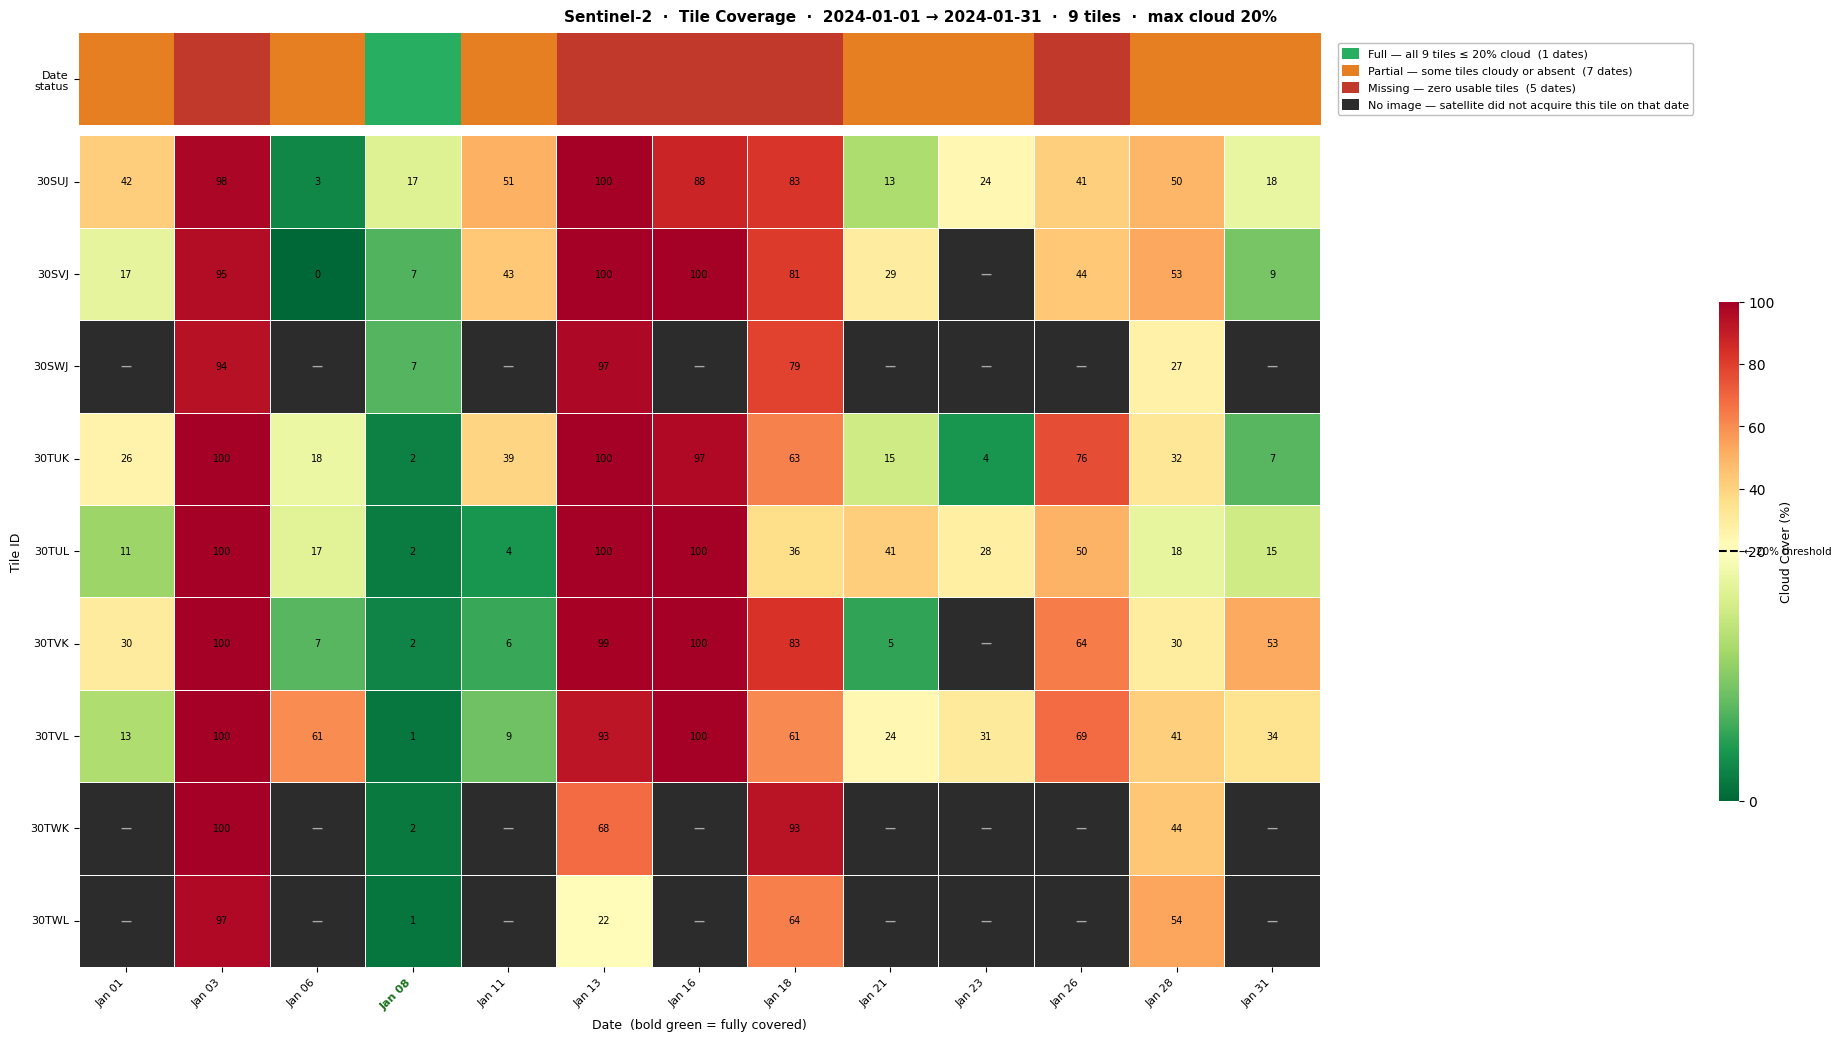

In [14]:
fig = plot_coverage_heatmap(cov, max_cloud=max_cloud, satellite='Sentinel-2')

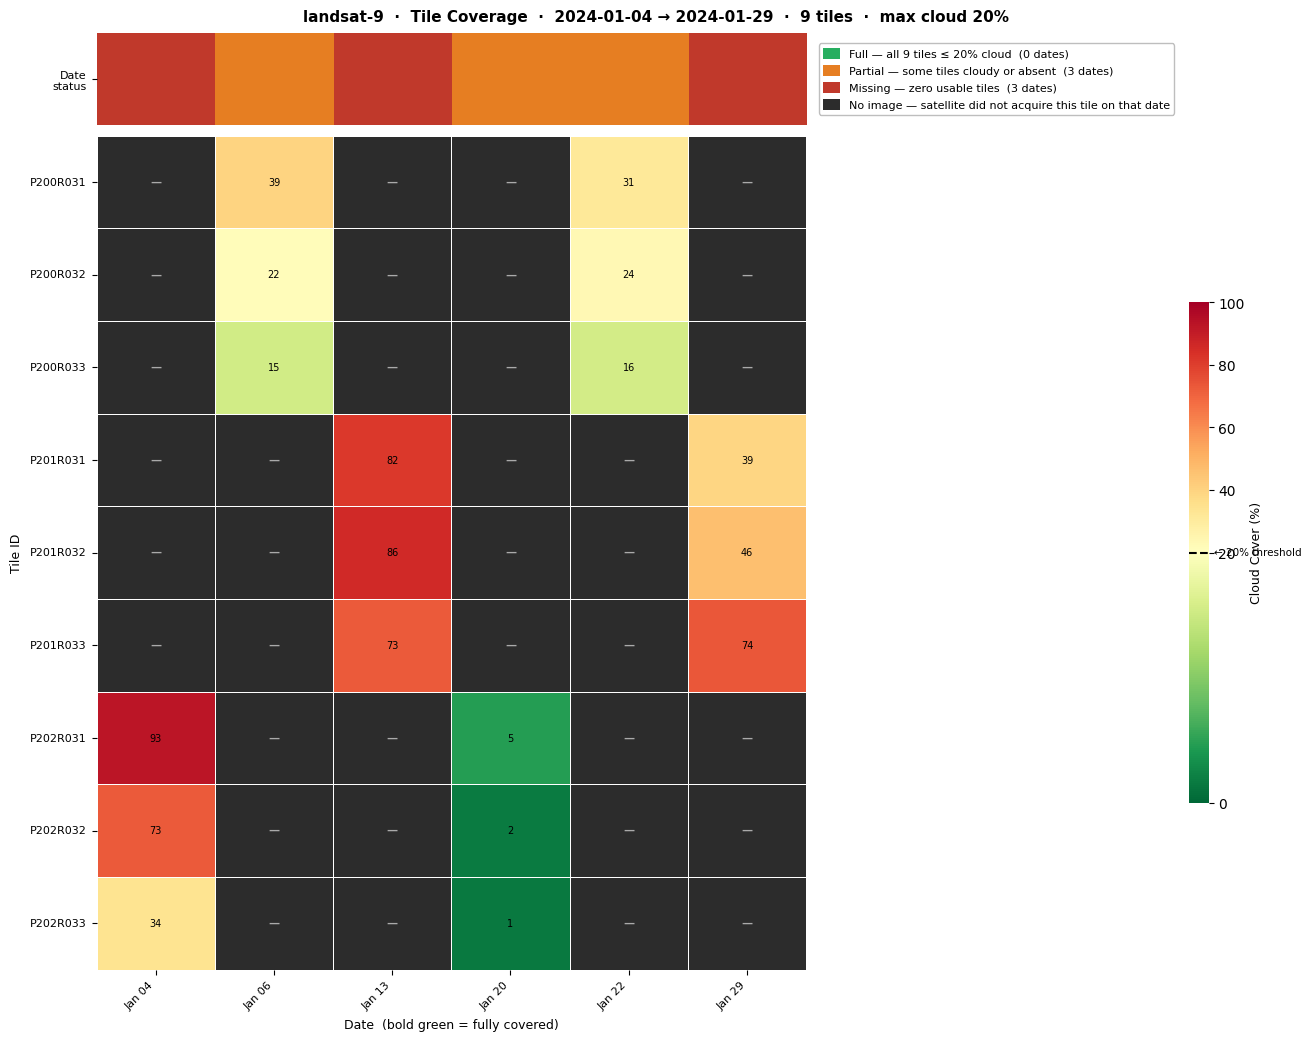

In [15]:
fig = plot_coverage_heatmap(cov, max_cloud=max_cloud, satellite='landsat-9')

## 9. Spatial tile map
Interactive map — tiles coloured by how often they fall below the cloud threshold.

In [16]:
import folium
from collections import defaultdict

bbox_country = [-9.3, 35.9, 4.3, 43.8]   # all Spain

print('Fetching Spain-wide tile data for spatial map (may take ~30 s)...')
cov_country = check_coverage(bbox_country, start_date, end_date,
                              max_cloud=max_cloud, satellites=['sentinel2'])
print(f'Done — {len(set(t for c in cov_country for t in c.required_tiles))} tiles')

Fetching Spain-wide tile data for spatial map (may take ~30 s)...


Done — 146 tiles


In [17]:
tile_stats = defaultdict(lambda: {'clouds': [], 'geometry': None})
for c in cov_country:
    for tr in c.tile_details:
        ts = tile_stats[tr.tile_id]
        if tr.geometry and ts['geometry'] is None:
            ts['geometry'] = tr.geometry
        if tr.cloud_cover != -1:
            ts['clouds'].append(tr.cloud_cover)

def tile_color(clouds, threshold):
    if not clouds: return '#7f8c8d'
    usable = sum(1 for c in clouds if c <= threshold) / len(clouds)
    if usable >= 0.5: return '#27ae60'
    if usable >= 0.2: return '#e67e22'
    if usable  > 0:   return '#e74c3c'
    return '#7f8c8d'

aoi_bbox = to_bbox(aoi)
m = folium.Map(location=[40.0, -3.5], zoom_start=6, tiles='CartoDB positron')

folium.Rectangle(
    bounds=[[aoi_bbox[1], aoi_bbox[0]], [aoi_bbox[3], aoi_bbox[2]]],
    color='#1a73e8', weight=3, fill=True, fill_opacity=0.10,
    tooltip='Coverage analysis area (Madrid region)'
).add_to(m)

for tile_id, ts in tile_stats.items():
    if not ts['geometry']: continue
    clouds  = ts['clouds']
    color   = tile_color(clouds, max_cloud)
    best    = f'{min(clouds):.1f}' if clouds else 'N/A'
    usable  = sum(1 for c in clouds if c <= max_cloud)
    total   = len(clouds)
    tooltip = (
        f'<b>Tile {tile_id}</b><br>'
        f'Best cloud cover: {best}%<br>'
        f'Usable / total: {usable} / {total}'
    )
    folium.GeoJson(
        ts['geometry'],
        style_function=lambda _, c=color: {
            'fillColor': c, 'color': 'white',
            'weight': 1.2, 'fillOpacity': 0.55
        },
        tooltip=folium.Tooltip(tooltip, sticky=False)
    ).add_to(m)

legend = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:12px 16px;border-radius:8px;
            border:1px solid #ccc;font-size:12px;line-height:2">
  <b>Tile usability</b><br>
  <span style="background:#27ae60;padding:2px 14px;border-radius:3px">&nbsp;</span> &ge;50% of dates usable<br>
  <span style="background:#e67e22;padding:2px 14px;border-radius:3px">&nbsp;</span> 20&ndash;50% usable<br>
  <span style="background:#e74c3c;padding:2px 14px;border-radius:3px">&nbsp;</span> &lt;20% usable<br>
  <span style="background:#7f8c8d;padding:2px 14px;border-radius:3px">&nbsp;</span> No data<br>
  <span style="background:#1a73e8;padding:2px 14px;border-radius:3px;opacity:0.4">&nbsp;</span> Analysis area
</div>
'''
m.get_root().html.add_child(folium.Element(legend))
m

## 10. Different region — Uganda (GeoJSON FeatureCollection)

Same library, different AOI format and region.

In [18]:
ug_aoi = {
    'type': 'FeatureCollection',
    'features': [{
        'type': 'Feature',
        'geometry': {
            'type': 'Polygon',
            'coordinates': [[
                [29.58, -1.44], [35.04, -1.44],
                [35.04,  4.25], [29.58,  4.25],
                [29.58, -1.44],
            ]]
        },
        'properties': {}
    }]
}

ug_images = search_images(
    ug_aoi,
    '2023-01-01', '2023-01-31',
    max_cloud=20,
    satellites=['sentinel2'],
)
print(f'Uganda — {len(ug_images)} Sentinel-2 scenes in Jan 2023')

Uganda — 313 Sentinel-2 scenes in Jan 2023
